# Imports

In [10]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import f1_score
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

from sklearn.ensemble import GradientBoostingClassifier
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.base import clone

# Carga do Dataset

O dataset contém informações sobre vários estudantes, com cada registro representando uma pessoa. **As variáveis incluem características médicas, medidas de saúde e a presença ou ausência de diabetes. A última coluna, Outcome, indica se a paciente tem diabetes (1) ou não (0).**

Descrição de Cada Coluna
- Pregnancies: ....

O objetivo é prever se um aluno vai finalizar a graduação ou abandonar.

In [11]:
from pathlib import Path


caminho_pasta = Path.cwd().resolve()
dataset_filename = caminho_pasta / 'data' / 'dataset.csv'


students_dataframe = pd.read_csv(dataset_filename, delimiter=';')
students_dataframe.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


## Pré-Processamento de Dados
Será necessário apagar algumas colunas que não tiveram impacto significativo no modelo

In [12]:
colunas_para_remover = ["Unemployment rate", "Inflation rate", "GDP"]
students_dataframe = students_dataframe.drop(columns=colunas_para_remover)
students_dataframe.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0.000000,0,0,0,0,0,0.000000,0,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,6,14.000000,0,0,6,6,6,13.666667,0,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,0.000000,0,0,6,0,0,0.000000,0,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,6,13.428571,0,0,6,10,5,12.400000,0,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,5,12.333333,0,0,6,6,6,13.000000,0,Graduate


In [13]:
## Avaliar os tipos das colunas
# students_dataframe.dtypes
# students_dataframe['Target'].unique()
students_dataframe['Target'].value_counts()
students_dataframe.shape

(4424, 34)

In [14]:
test_size = 0.20
seed = 7

# Separação em conjuntos de treino e teste
X = students_dataframe.iloc[:,0:-1]
y = students_dataframe.iloc[:,-1]
X_train, X_test, y_train, y_test = train_test_split(X, y,
    test_size=test_size, shuffle=True, random_state=seed, stratify=y)

# Parâmetros e partições da validação cruzada
scoring = 'f1_weighted'
num_particoes = 10
kfold = StratifiedKFold(n_splits=num_particoes, shuffle=True, random_state=seed)

## Modelagem e Inferência

### Modelos sem Padronizar ou Normalizar Dados

LR: 0.649495 (0.020275)
KNN: 0.580805 (0.025687)
CART: 0.678008 (0.019466)
NB: 0.673499 (0.013242)
SVM: 0.332551 (0.001607)
GB: 0.757332 (0.010150)


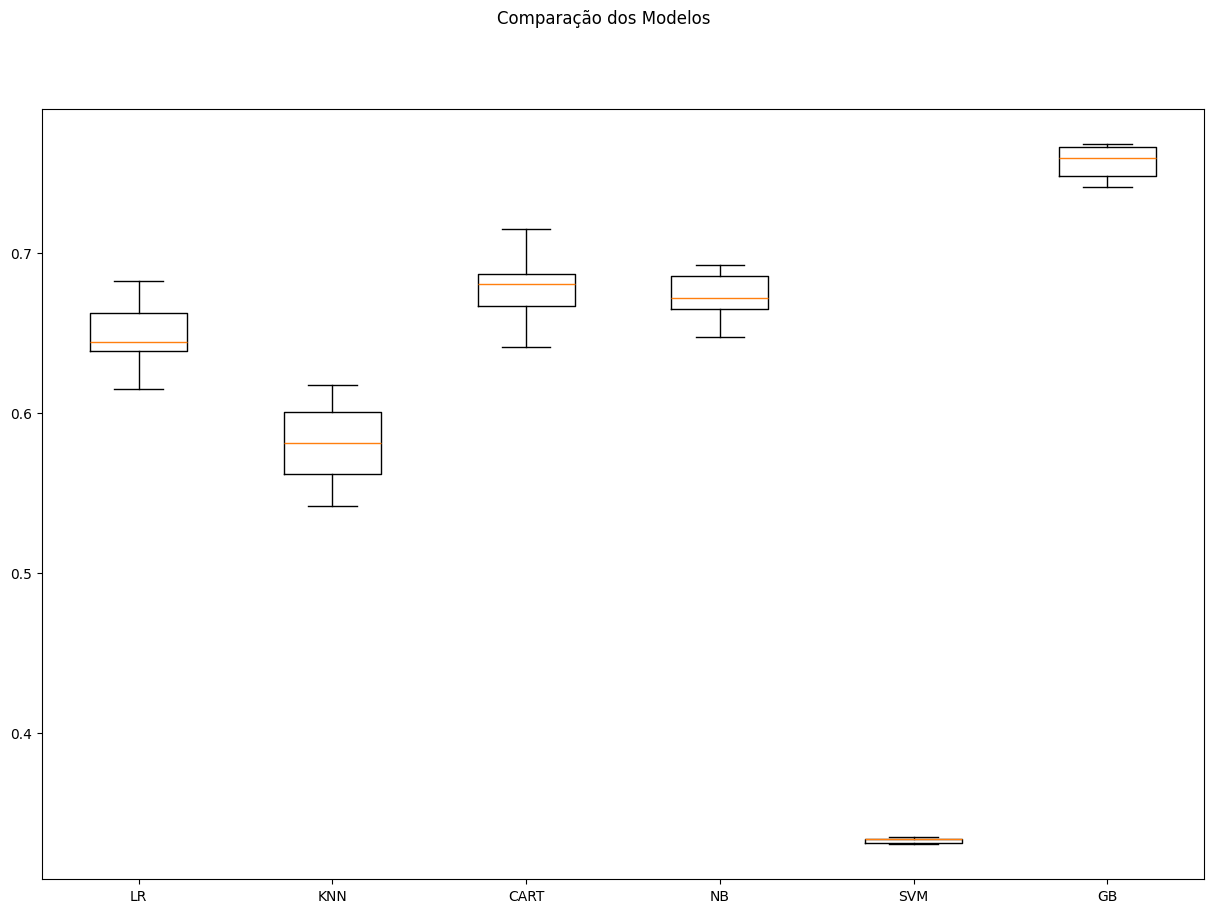

In [15]:
np.random.seed(seed)

models = []
num_trees = 100
max_features = "sqrt"

models.append(('LR', LogisticRegression(max_iter=200))) 
models.append(('KNN', KNeighborsClassifier())) 
models.append(('CART', DecisionTreeClassifier())) 
models.append(('NB', GaussianNB()))
models.append(('SVM', SVC()))
models.append(('GB', GradientBoostingClassifier(n_estimators=num_trees)))

# Listas para armazenar os resultados
results = []
names = []


for name, model in models:
    cv_results = cross_val_score(model, X_train, y_train, cv=kfold, scoring=scoring)
    results.append(cv_results)
    names.append(name)
    msg = "%s: %f (%f)" % (name, cv_results.mean(), cv_results.std())
    print(msg)

# Boxplot de comparação dos modelos
fig = plt.figure(figsize=(15,10)) 
fig.suptitle('Comparação dos Modelos') 
ax = fig.add_subplot(111) 
plt.boxplot(results) 
ax.set_xticklabels(names) 
plt.show()

## Desbalanceamento de Classes
O conjunto de dados apresenta uma distribuição desbalanceada entre as classes-alvo Graduate, Dropout e Enrolled, o que pode introduzir viés no processo de aprendizado dos modelos. Em cenários com desbalanceamento, classificadores tendem a favorecer a classe majoritária, comprometendo métricas como recall e F1-score nas classes minoritárias. Para mitigar esse efeito, será aplicada a técnica SMOTE (Synthetic Minority Oversampling Technique), que gera amostras sintéticas para as classes sub-representadas com base na interpolação entre instâncias existentes.

### Distribuição antes de realizar SMOTE

Graduate    2209

Dropout     1421

Enrolled     794


LR: 0.683 (+/- 0.019)
KNN: 0.536 (+/- 0.019)
CART: 0.662 (+/- 0.020)
NB: 0.658 (+/- 0.027)
SVM: 0.279 (+/- 0.111)
GB: 0.762 (+/- 0.018)


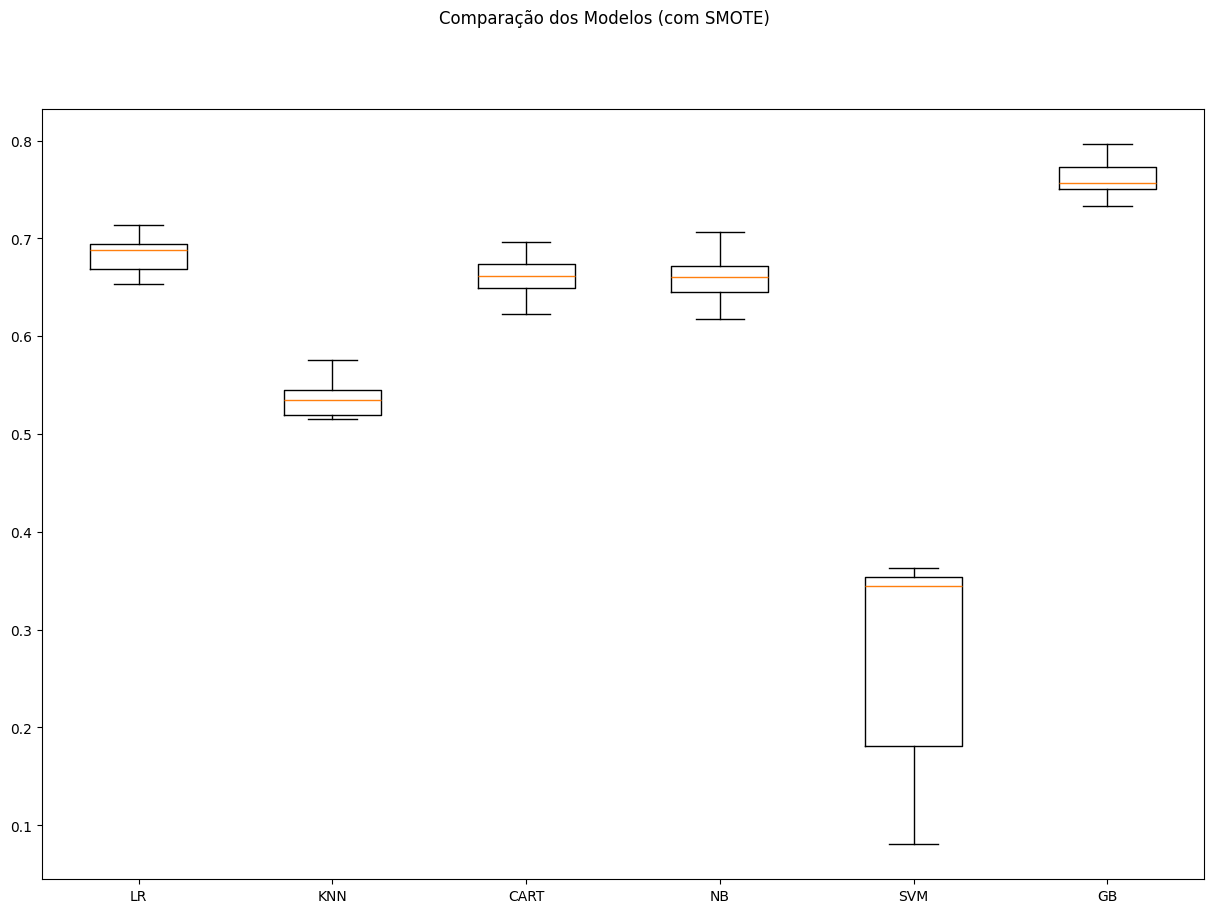

In [16]:

base_models = []
num_trees = 100

base_models.append(('LR',   LogisticRegression(max_iter=200, random_state=seed)))
base_models.append(('KNN',  KNeighborsClassifier()))
base_models.append(('CART', DecisionTreeClassifier(random_state=seed)))
base_models.append(('NB',   GaussianNB()))
base_models.append(('SVM',  SVC(cache_size=500, random_state=seed)))
base_models.append(('GB',   GradientBoostingClassifier(n_estimators=num_trees, random_state=seed)))

smote_results = []
names = []

# Aplicaçao do SMOTE
for name, model in base_models:
    pipeline = ImbPipeline([
        ('smote', SMOTE(random_state=seed)),
        ('model', model)
    ])
    smote_cv_results = cross_val_score(
        pipeline, X_train, y_train, cv=kfold, scoring=scoring,
        n_jobs=-1
    )
    smote_results.append(smote_cv_results)
    names.append(name)
    print(f"{name}: {smote_cv_results.mean():.3f} (+/- {smote_cv_results.std():.3f})")

# Boxplot
fig = plt.figure(figsize=(15, 10))
fig.suptitle('Comparação dos Modelos (com SMOTE)')
ax = fig.add_subplot(111)
plt.boxplot(smote_results)
ax.set_xticklabels(names)
plt.show()

# Tabela comparativa Antes e Depois

In [17]:
# listas vazias para armazenar médias
medias_original = []
medias_smote = []

for valor in results:
    medias_original.append(valor.mean())

for valor in smote_results:
    medias_smote.append(valor.mean())

tabela_comparativa = pd.DataFrame({
    'Modelo':        names,
    'Sem SMOTE':     medias_original,
    'Com SMOTE':     medias_smote,
})

# coluna com diferença
tabela_comparativa['Δ'] = tabela_comparativa['Com SMOTE'] - tabela_comparativa['Sem SMOTE']

tabela_comparativa = tabela_comparativa.round(3)
tabela_comparativa

,Modelo,Sem SMOTE,Com SMOTE,Δ
0,LR,0.649,0.683,0.034
1,KNN,0.581,0.536,-0.045
2,CART,0.678,0.662,-0.016
3,NB,0.673,0.658,-0.016
4,SVM,0.333,0.279,-0.054
5,GB,0.757,0.762,0.004


### Criação e avaliação de modelos: dados padronizados e normalizados

LR-padr: 0.740 (0.014)
LR-norm: 0.735 (0.017)
LR-padr+smote: 0.749 (0.019)
LR-norm+smote: 0.741 (0.016)
KNN-padr: 0.689 (0.012)
KNN-norm: 0.670 (0.016)
KNN-padr+smote: 0.642 (0.020)
KNN-norm+smote: 0.628 (0.028)
CART-padr: 0.677 (0.013)
CART-norm: 0.676 (0.020)
CART-padr+smote: 0.665 (0.023)
CART-norm+smote: 0.680 (0.017)
NB-padr: 0.668 (0.013)
NB-norm: 0.668 (0.013)
NB-padr+smote: 0.680 (0.021)
NB-norm+smote: 0.674 (0.024)
SVM-padr: 0.737 (0.017)
SVM-norm: 0.720 (0.016)
SVM-padr+smote: 0.741 (0.023)
SVM-norm+smote: 0.739 (0.021)
GB-padr: 0.757 (0.011)
GB-norm: 0.758 (0.011)
GB-padr+smote: 0.759 (0.017)
GB-norm+smote: 0.761 (0.014)


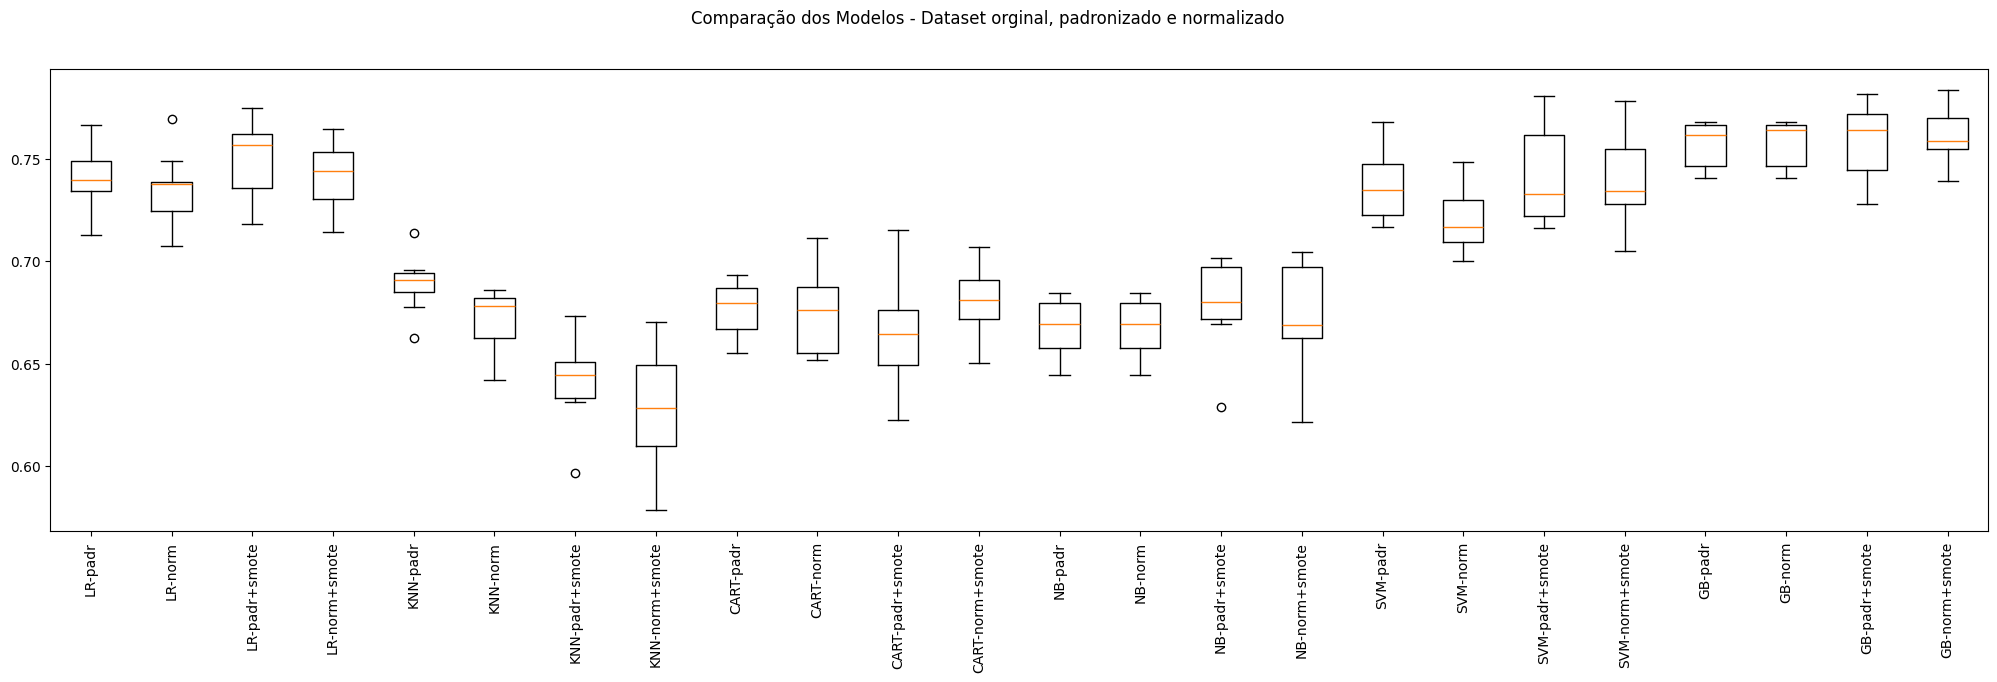

In [18]:
np.random.seed(seed)

pipelines = []
results_preprocessed = []
names = []

new_models = []

new_models.append(('LR',   LogisticRegression(max_iter=200)))
new_models.append(('KNN',  KNeighborsClassifier()))
new_models.append(('CART', DecisionTreeClassifier()))
new_models.append(('NB',   GaussianNB()))
new_models.append(('SVM',  SVC(cache_size=500)))
new_models.append(('GB',   GradientBoostingClassifier(n_estimators=num_trees)))


# Definindo os componentes do pipeline
standard_scaler = StandardScaler()
min_max_scaler = MinMaxScaler()
smote = ('SMOTE', SMOTE(random_state=seed))


# Criando pipelines para cada modelo
for name, model in new_models:
    pipelines.append((name + '-padr', Pipeline(steps=[('StandardScaler', clone(standard_scaler)), (name, model)])))
    pipelines.append((name + '-norm', Pipeline(steps=[('MinMaxScaler', clone(min_max_scaler)), (name, model)])))
    pipelines.append((name + '-padr+smote', ImbPipeline(steps=[('StandardScaler', clone(standard_scaler)), smote, (name, model)])))
    pipelines.append((name + '-norm+smote', ImbPipeline(steps=[('MinMaxScaler', clone(min_max_scaler)), smote, (name, model)])))


# Executando os pipelines
for name, model in pipelines:
    cv_results = cross_val_score(model, X_train, y_train, cv=kfold, scoring=scoring, n_jobs=-1)
    results_preprocessed.append(cv_results)
    names.append(name)
    msg = "%s: %.3f (%.3f)" % (name, cv_results.mean(), cv_results.std()) # formatando para 3 casas decimais
    print(msg)

# Boxplot de comparação dos modelos
fig = plt.figure(figsize=(25,6))
fig.suptitle('Comparação dos Modelos - Dataset orginal, padronizado e normalizado') 
ax = fig.add_subplot(111) 
plt.boxplot(results_preprocessed) 
ax.set_xticklabels(names, rotation=90)
plt.show()


# Grid Search

## Todos os modelos

In [19]:
np.random.seed(seed)

# Definindo os parâmetros para GridSearchCV
param_grids = {
    'LR': {
        'LR__C': [0.01, 0.1, 1, 10, 100],
        'LR__solver': ['liblinear', 'saga']
    },
    'KNN': {
        'KNN__n_neighbors': [1, 3, 5, 7, 9, 11, 13, 15, 17, 19, 21],
        'KNN__metric': ["euclidean", "manhattan", "minkowski"]
    },
    'CART': {
        'CART__max_depth': [None, 10, 20, 30, 40, 50],
        'CART__min_samples_split': [2, 5, 10],
        'CART__min_samples_leaf': [1, 2, 4]
    },
    'NB': {
        'NB__var_smoothing': [1e-9, 1e-8, 1e-7, 1e-6, 1e-5]
    },
    'SVM': [
        {
            'SVM__kernel': ['linear'],
            'SVM__C': [0.1, 1, 10, 100]
        },
        {
            'SVM__kernel': ['rbf'],
            'SVM__C': [0.1, 1, 10, 100],
            'SVM__gamma': [1, 0.1, 0.01, 0.001]
        }
    ],
    # 'GB': {
    #     'GB__n_estimators': [10, 50, 100, 200],
    #     'GB__learning_rate': [0.01, 0.1, 0.2, 0.3],
    #     'GB__max_depth': [3, 5, 7, 9]
    # }
}

# Parâmetros de cross-validation e scoring
scoring = 'f1_weighted'
kfold = 5

# Executando o GridSearchCV para cada pipeline
for name, pipeline in pipelines:
    model_type = name.split('-')[0]
    if model_type in param_grids:
        param_grid = param_grids[model_type]
    else:
        param_grid = {}  # Para modelos que não têm parâmetros definidos

    grid = GridSearchCV(
        estimator=pipeline, param_grid=param_grid, scoring=scoring, cv=kfold,
        n_jobs=-1,
        refit=True,
        )
    grid.fit(X_train, y_train)
    # Imprimindo a melhor configuração
    print("Modelo: %s - Melhor: %f usando %s" % (name, grid.best_score_, grid.best_params_))

# 130 min
    

Modelo: LR-padr - Melhor: 0.740997 usando {'LR__C': 100, 'LR__solver': 'saga'}
Modelo: LR-norm - Melhor: 0.740971 usando {'LR__C': 10, 'LR__solver': 'saga'}
Modelo: LR-padr+smote - Melhor: 0.751338 usando {'LR__C': 1, 'LR__solver': 'saga'}
Modelo: LR-norm+smote - Melhor: 0.750264 usando {'LR__C': 10, 'LR__solver': 'saga'}
Modelo: KNN-padr - Melhor: 0.707892 usando {'KNN__metric': 'manhattan', 'KNN__n_neighbors': 11}
Modelo: KNN-norm - Melhor: 0.693254 usando {'KNN__metric': 'manhattan', 'KNN__n_neighbors': 5}
Modelo: KNN-padr+smote - Melhor: 0.704336 usando {'KNN__metric': 'manhattan', 'KNN__n_neighbors': 13}
Modelo: KNN-norm+smote - Melhor: 0.680836 usando {'KNN__metric': 'manhattan', 'KNN__n_neighbors': 7}
Modelo: CART-padr - Melhor: 0.721947 usando {'CART__max_depth': 10, 'CART__min_samples_leaf': 1, 'CART__min_samples_split': 2}
Modelo: CART-norm - Melhor: 0.720913 usando {'CART__max_depth': 10, 'CART__min_samples_leaf': 1, 'CART__min_samples_split': 5}
Modelo: CART-padr+smote - Me

# Resultados Finais e Considerações - Escolhendo o melhor modelo

Modelo: GB-padr+smote - Melhor: 0.764749 usando {'GB__learning_rate': 0.2, 'GB__max_depth': 5, 'GB__n_estimators': 50}

Modelo: GB-norm+smote - Melhor: 0.769390 usando {'GB__learning_rate': 0.1, 'GB__max_depth': 5, 'GB__n_estimators': 100}

Modelo: SVM-padr+smote - Melhor: 0.751548 usando {'SVM__C': 100, 'SVM__gamma': 0.001, 'SVM__kernel': 'rbf'}

## Avaliando o desempenho do modelo com os dados de teste
Modelo: GB-norm+smote - Melhor: 0.769390 usando {'GB__learning_rate': 0.1, 'GB__max_depth': 5, 'GB__n_estimators': 100}

In [20]:
from sklearn.metrics import classification_report

best_model = GradientBoostingClassifier(
    learning_rate=0.1,
    max_depth=5,
    n_estimators=100,
    random_state=seed
)
scaler = ('MinMaxScaler', MinMaxScaler())
smote = ('SMOTE', SMOTE(random_state=seed))

best_pipeline = ImbPipeline(steps=[
                    scaler,
                    smote,
                    ('GB', best_model)
                    ])


best_pipeline.fit(X_train, y_train)


predictions = best_pipeline.predict(X_test)
print(f1_score(y_test, predictions, average='weighted'))
print(classification_report(y_test, predictions))

0.7746543509376683
              precision    recall  f1-score   support

     Dropout       0.81      0.76      0.79       284
    Enrolled       0.55      0.48      0.51       159
    Graduate       0.83      0.90      0.86       442

    accuracy                           0.78       885
   macro avg       0.73      0.71      0.72       885
weighted avg       0.77      0.78      0.77       885



## Teste 2 (descartado)
Modelo: SVM-padr+smote - Melhor: 0.760531 usando {'SVM__C': 100, 'SVM__gamma': 0.001, 'SVM__kernel': 'rbf'}

In [21]:
from sklearn.metrics import classification_report

np.random.seed(seed)

best_model = SVC(
    C=100,
    gamma=0.001,
    kernel='rbf'
)

best_pipeline = ImbPipeline(steps=[
                    ('StandardScaler', StandardScaler()),
                    ('SMOTE', SMOTE(random_state=seed)),
                    ('SVM', best_model)
                    ])


best_pipeline.fit(X_train, y_train)


predictions = best_pipeline.predict(X_test)
print(f1_score(y_test, predictions, average='weighted'))
print(classification_report(y_test, predictions))

0.7642325572285924
              precision    recall  f1-score   support

     Dropout       0.87      0.70      0.78       284
    Enrolled       0.46      0.68      0.55       159
    Graduate       0.85      0.81      0.83       442

    accuracy                           0.75       885
   macro avg       0.73      0.73      0.72       885
weighted avg       0.79      0.75      0.76       885



## Teste 3 (descartado)

Modelo: GB-padr+smote - Melhor: 0.766889 usando {'GB__learning_rate': 0.1, 'GB__max_depth': 7, 'GB__n_estimators': 200}

In [22]:
from sklearn.metrics import classification_report

best_model = GradientBoostingClassifier(
    learning_rate=0.1,
    max_depth=7,
    n_estimators=200,
    random_state=seed
)

best_pipeline = ImbPipeline(steps=[
                    ('StandardScaler', StandardScaler()),
                    ('SMOTE', SMOTE(random_state=seed)),
                    ('GB', best_model)
                    ])


best_pipeline.fit(X_train, y_train)


predictions = best_pipeline.predict(X_test)
print(f1_score(y_test, predictions, average='weighted'))
print(classification_report(y_test, predictions))

0.7516760738757895
              precision    recall  f1-score   support

     Dropout       0.78      0.76      0.77       284
    Enrolled       0.52      0.40      0.45       159
    Graduate       0.81      0.89      0.85       442

    accuracy                           0.76       885
   macro avg       0.70      0.68      0.69       885
weighted avg       0.75      0.76      0.75       885



# Salvando

In [23]:
# Salvando o modelo
model_filename = 'gb_students_classifier.pkl'
with open("models/"+model_filename, 'wb') as file:
    pickle.dump(best_model, file)

# Salvando o scaler
scaler_filename = 'minmax_scaler_students.pkl'
with open("models/"+scaler_filename, 'wb') as file:
    pickle.dump(scaler, file)
    
# Salvando o pipeline
pipeline_filename = 'students_pipeline.pkl'
with open("models/"+pipeline_filename, 'wb') as file:
    pickle.dump(best_pipeline, file)
    
# Salvando X_test e y_test
X_test_df = pd.DataFrame(X_test, columns=students_dataframe.columns[:-1])
y_test_df = pd.DataFrame(y_test, columns=[students_dataframe.columns[-1]])
X_test_df.to_csv("data/X_test_dataset_students.csv", index=False)
y_test_df.to_csv("data/y_test_dataset_students.csv", index=False)

# Simulando a aplicação do modelo em dados não vistos

In [27]:

dados_in = [[
    2, 39, 1, 8014, 0, 1, 100.0, 1, 37, 38, 9, 9, 141.5, 
    0, 0, 0, 1, 0, 0, 45, 0, 0, 6, 9, 5, 12.334, 0, 0, 
    6, 6, 6, 13.0, 0
]]
atributos = best_pipeline.feature_names_in_
dados_in_dataframe = pd.DataFrame(dados_in, columns=atributos)

nova_predicao = best_pipeline.predict(dados_in_dataframe)
probabilidades = best_pipeline.predict_proba(dados_in_dataframe)


print(f"A categoria prevista para o aluno é: {nova_predicao[0]}")
print(f"As probabilidades para cada classe são: {probabilidades[0]}")

A categoria prevista para o aluno é: Graduate
As probabilidades para cada classe são: [8.22526722e-04 6.62941848e-04 9.98514531e-01]
